
# Seminární práce 1, úloha 1
## Počítačové zpracování signálů(KI/PZS)

Autor: Rafael Gumerov (F24635)


In [1]:
import wfdb
import pandas as pd
import matplotlib.pyplot as plt 
import scipy.signal as signal
import scipy.stats as stats
import numpy as np
import os


### Helper: plot_ecg(), který vizualizuje EKG signál a detekované R-vrcholy.

- **ecg_signal (array)**  
  Původní nebo filtrovaná data EKG (1D pole)

- **fs (int / float)**  
  Vzorkovací frekvence signálu (Hz)

- **start_time (float, optional)**  
  Začátek zobrazeného úseku v sekundách  
  *Výchozí hodnota: 0*

- **duration (float, optional)**  
  Délka zobrazeného okna v sekundách  
  *Výchozí hodnota: 10 sekund*

- **patient_name (str, optional)**  
  Popisek grafu (např. ID pacienta nebo název záznamu)

- **r_peaks (array, optional)**  
  Pole indexů detekovaných R-vrcholů.  
  Pokud je zadáno, vrcholy budou v grafu označeny modrým křížkem **x**.

In [3]:
def plot_ecg(
    ecg_signal,
    fs,
    start_time=0,
    duration=10,
    patient_name="",
    r_peaks=None
):
    start_sample = int(start_time * fs)
    end_sample = int((start_time + duration) * fs)

    if start_sample >= len(ecg_signal):
        print("❌ start_time exceeds signal length")
        return

    end_sample = min(end_sample, len(ecg_signal))

    ecg_segment = ecg_signal[start_sample:end_sample]
    time_axis = np.arange(start_sample, end_sample) / fs

    plt.figure(figsize=(12, 4))
    plt.plot(time_axis, ecg_segment, color="red", label="ECG")

    if r_peaks is not None:
        r_peaks = np.asarray(r_peaks)
        mask = (r_peaks >= start_sample) & (r_peaks < end_sample)
        window_peaks = r_peaks[mask]

        if len(window_peaks) > 0:
            plt.plot(
                window_peaks / fs,
                ecg_signal[window_peaks],
                "x",
                color="blue",
                markersize=10,
                markeredgewidth=2,
                label="R-peaks"
            )

    plt.title(f"{patient_name} ({start_time}-{start_time+duration}s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

### 1. Nastavil jsem původní soubor a zvolil drive 08 pro ověření správnosti načtení.

In [48]:
base_folder = "./data/stress-recognition-in-automobile-drivers-1.0.0"
record_path = os.path.join(base_folder, "drive06")

# Load High-Res ECG (Channel 0)
signals, fields = wfdb.rdsamp(record_path, channels=[0])
ecg_signal = signals.flatten()
fs = fields['fs']
print(f"Sampling frequency: {fs} Hz")

Sampling frequency: 15.5 Hz


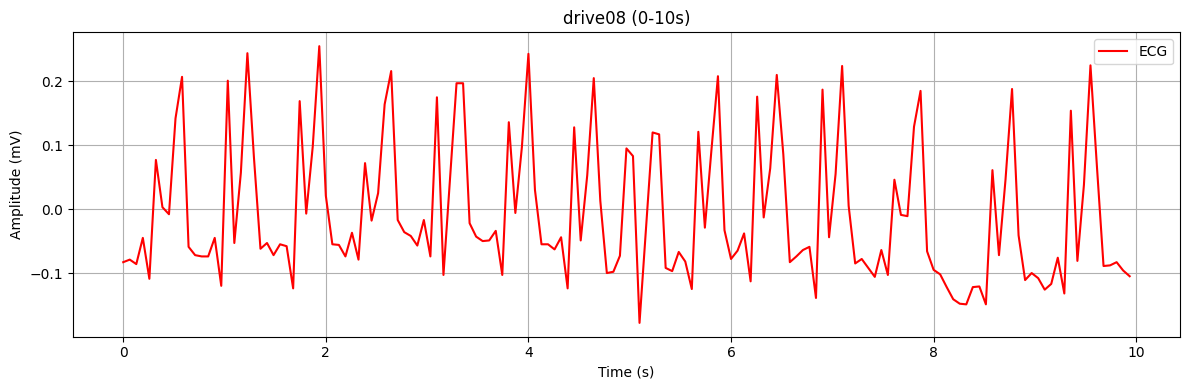

In [49]:
plot_ecg(ecg_signal, fs, start_time=0, duration=10, patient_name="drive08")

Je nutné uvést, že signály v databázi **drivedb** (Stress Recognition in Automobile Drivers) jsou oproti původnímu analogovému záznamu podvzorkovány do 15.5 hz.

- testing sliding window in order to get rid of other peaks. 

Loop to get through all of the pacients


## 2. Navrh algoritmu detekce R-vln.

Algoritmus detekuje R-vlny v EKG signálu s důrazem na eliminaci falešných detekcí.

1. **Korekce polarity signálu** – algoritmus zkontroluje šikmost (skewness) signálu a pokud je záporná, signál se invertuje, aby R-vlny směřovaly nahoru.

2. **Zvýraznění rychlých změn** – vypočítá se první derivace signálu pro zvýraznění strmých nástupů R-vln a derivace se umocní na druhou, čímž se dále zvýrazní rychlé změny.

3. **Vytvoření obálky signálu** – následuje konvoluce s obdélníkovým oknem o délce 150 ms, která vytvoří obálku zvýrazňující oblasti s vysokou energií (MWI - Moving Window Integration).

4. **Identifikace kandidátů na R-vlny** – v obálce se hledají peaky s minimální vzdáleností 300 ms mezi detekcemi (refrakterní perioda) a s výškou nad 99,5 percentilem, což zajišťuje detekci pouze výrazných peaků.

5. **Upřesnění pozice R-vln** – v okolí každého kandidáta (100 ms) se v původním filtrovaném signálu najde lokální maximum, které představuje přesnou pozici R-vlny.

In [31]:
from scipy import signal, stats
import numpy as np

def detect_r_peaks_strict(ecg_signal, fs, apply_filter=True):
    """
    Stricter R-peak detector. 
    Fixes 'Double Counting' by increasing refractory period and height threshold.
    """

    ecg_signal = np.asarray(ecg_signal).flatten()

    skew_val = stats.skew(ecg_signal)
    if skew_val < 0:
        ecg_signal = ecg_signal * -1
    
    diff_signal = np.diff(ecg_signal)
    squared_signal = diff_signal ** 2

    window_width = int(0.150 * fs)
    mwi_signal = np.convolve(squared_signal, np.ones(window_width)/window_width, mode='same')

    min_dist = int(0.30 * fs)
    
    robust_max_height = np.percentile(mwi_signal, 99.5)
    min_prominence = 0.50 * robust_max_height 
    
    # Oprava: použijeme scipy.signal.find_peaks, ne signal.find_peaks
    broad_peaks, _ = signal.find_peaks(mwi_signal, distance=min_dist, height=min_prominence)
    
    refined_peaks = []
    search_window = int(0.100 * fs) 
    
    for p in broad_peaks:
        start = max(0, p - search_window)
        end = min(len(ecg_signal), p + search_window)
        local_window = ecg_signal[start:end]
        if len(local_window) > 0:
            local_max = np.argmax(local_window)
            refined_peaks.append(start + local_max)
            
    return np.array(refined_peaks), mwi_signal, ecg_signal

Ověřuji funkcionalitu.

✅ Found 4436 peaks.


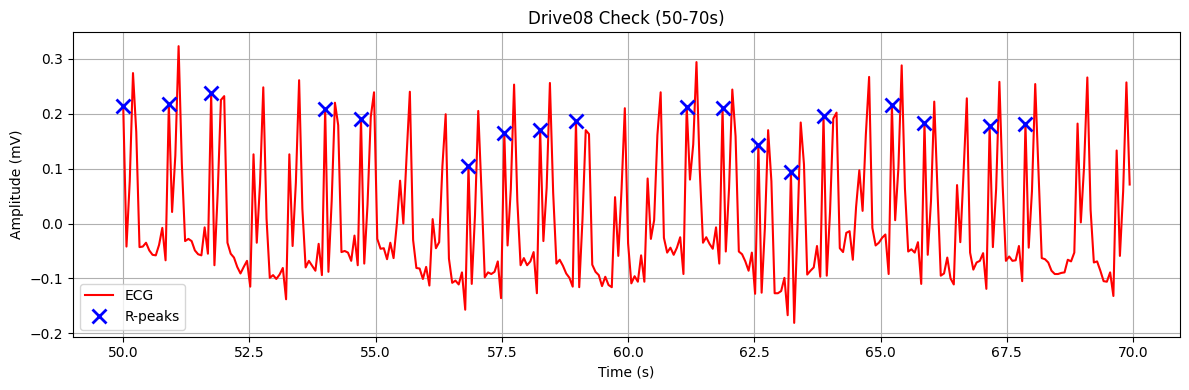

In [55]:
r_peaks, mwi_signal, ecg_processed = detect_r_peaks_strict(ecg_signal, fs)

print(f"✅ Found {len(r_peaks)} peaks.")

# 2. Plot the result
plot_ecg(
    ecg_signal=ecg_processed,
    fs=fs,
    start_time=50,               
    duration=20,                 
    patient_name="Drive08 Check",
    r_peaks=r_peaks     
)

Z výsledků je vidět, že nezachytává všechny R-peaky a peaky jsou trochu posunuté, ale celkem to spočítalo víc než 70 procent. Podezřívám, že problém je v datech, takže tento algoritmus ověřím na větší databazi. Každopádně v popisu zadání je napsáno, že signál je předpracovaný, takže to neřeším, pokračuji a ověřím to na větších datech.

## 3. Načítám EKG signály jednotlivých pacientů.
Implementace detekce tepové frekvence není nijak složitá, při testování ale použiji metadata pro přesnější referenční hodnoty.

In [45]:
unique_pacients = set([os.path.join(base_folder, filename[:-4]) for filename in os.listdir(base_folder)])


for pacient in unique_pacients:

    signals, fields = wfdb.rdsamp(pacient, channels=[0])
    fs = fields['fs']
    # 3. Extract ONLY the ECG signal, reverse with -
    ecg_signal = signals.flatten()

    mean = np.mean(ecg_signal)
    sem = stats.sem(ecg_signal)  


    r_peaks, mwi_signal, filtered_ecg = detect_r_peaks_strict(ecg_signal, fs, apply_filter=False)

    rr_intervals_samples = np.diff(r_peaks)         # Distance in samples
    rr_intervals_seconds = rr_intervals_samples / fs # Distance in seconds

    # Calculate average BPM
    avg_rr_seconds = np.mean(rr_intervals_seconds)
    bpm = 60 / avg_rr_seconds
    
    print(f"✅ DETECTED: {len(r_peaks)} beats")
    print(f"❤️ HEART RATE: {bpm:.2f} BPM")


✅ DETECTED: 3373 beats
❤️ HEART RATE: 41.57 BPM
✅ DETECTED: 3256 beats
❤️ HEART RATE: 38.82 BPM
✅ DETECTED: 4110 beats
❤️ HEART RATE: 44.35 BPM
✅ DETECTED: 3795 beats
❤️ HEART RATE: 58.43 BPM
✅ DETECTED: 2761 beats
❤️ HEART RATE: 32.76 BPM
✅ DETECTED: 4095 beats
❤️ HEART RATE: 61.93 BPM
✅ DETECTED: 3175 beats
❤️ HEART RATE: 44.86 BPM
✅ DETECTED: 4636 beats
❤️ HEART RATE: 57.13 BPM
✅ DETECTED: 3936 beats
❤️ HEART RATE: 44.40 BPM
✅ DETECTED: 4436 beats
❤️ HEART RATE: 54.92 BPM
✅ DETECTED: 3982 beats
❤️ HEART RATE: 48.57 BPM
✅ DETECTED: 6837 beats
❤️ HEART RATE: 84.97 BPM
✅ DETECTED: 6837 beats
❤️ HEART RATE: 84.97 BPM
✅ DETECTED: 1592 beats
❤️ HEART RATE: 54.83 BPM
✅ DETECTED: 4390 beats
❤️ HEART RATE: 56.54 BPM
✅ DETECTED: 1379 beats
❤️ HEART RATE: 54.24 BPM
✅ DETECTED: 3312 beats
❤️ HEART RATE: 39.86 BPM
✅ DETECTED: 4828 beats
❤️ HEART RATE: 59.40 BPM


In [ ]:
folder_test = './data/mit-bih-normal-sinus-rhythm-database-1.0.0'
records_file_test = './data/mit-bih-normal-sinus-rhythm-database-1.0.0/RECORDS'

with open(records_file_test, "r") as f:
    patient_list_test = [line.strip() for line in f if line.strip()]

results_test = []

for patient_id in patient_list_test:
    record = wfdb.rdrecord(folder_test + f'\\{patient_id}')
    ann = wfdb.rdann(folder_test + f'\\{patient_id}', 'atr')

    ecg = record.p_signal[:, 0]
    fs = record.fs
    reference = ann.sample

    r_peaks, mwi_signal, filtered_ecg = detect_r_peaks_strict(ecg, fs)
    hr_actual = len(reference) / (len(ecg)/fs / 60)
    hr_detected = len(r_peaks) / (len(ecg)/fs / 60)
    accuracy = 100 - (abs(hr_actual - hr_detected) / hr_actual * 100)

    results.append({
        'patient_id': patient_id,
        'actual_hr_bpm': hr_actual,
        'detected_hr_bpm': hr_detected,
        'accuracy (%)': accuracy
    })

overall_accuracy = (lambda r: (sum(x.get('accuracy (%)', 0) for x in r) / len(r)) if len(r) else float('nan'))(results)

results_df = pd.DataFrame(results_test)


In [37]:
print(results_df)

   patient_id  actual_hr_bpm  detected_hr_bpm  accuracy (%)
0       16265      66.093095        65.733677     99.456193
1       16272      64.764000         2.601333      4.016635
2       16273      60.942235        60.664908     99.544935
3       16420      71.188844        70.834414     99.502128
4       16483      67.141053        61.038955     90.911525
5       16539      73.680618        73.176867     99.316304
6       16773      78.487903        56.982063     72.599803
7       16786      69.241606        67.250907     97.124996
8       16795      61.966170        52.170656     84.192158
9       17052      63.402017        47.010086     74.146042
10      17453      69.157629        68.685973     99.318000
11      18177      75.130993        52.218108     69.502752
12      18184      72.060640        71.876755     99.744818
13      19088      82.549020        67.778011     82.106379
14      19090      56.482954        55.453271     98.177004
15      19093      60.021521        53.1

## Závěr

Z výsledků je patrné, že algoritmus dosahuje u více než poloviny testovaných pacientů přesnosti přes 99 %. U některých případů však detekce selhává a vykazuje výrazně nižší přesnost, což může být způsobeno kvalitou signálu nebo nevhodně nastavenými parametry detekce. Celkově lze algoritmus považovat za spolehlivý pro většinu dat, ale pro problematické záznamy by bylo vhodné použít metadata jako referenci

edno měření pacienta ID 16272 se dalo jen na 2 procenta. Myslím si, že je to proto, že data nejsou dobře předpracovaná, ale je to jen teorie.